In [3]:
import pandas as pd
from pathlib import Path


In [3]:
chemin_dossier = r"C:\Users\DELL\Desktop\Masteroffic\Mastere Data engenner\M1\ETL\projet\projetetlimolocal\data\raw"
nom_fichier = "transactions_sample.csv"
chemin_complet = f"{chemin_dossier}\\{nom_fichier}"
df = pd.read_csv(chemin_complet)
print(df.columns)

Index(['id_transaction', 'date_transaction', 'prix', 'departement', 'id_ville',
       'ville', 'code_postal', 'adresse', 'type_batiment', 'vefa', 'n_pieces',
       'surface_habitable', 'id_parcelle_cadastre', 'latitude', 'longitude',
       'surface_dependances', 'surface_locaux_industriels',
       'surface_terrains_agricoles', 'surface_terrains_sols',
       'surface_terrains_nature'],
      dtype='object')


In [9]:
dossier = Path("data/raw")

dossier = Path(r"C:\Users\DELL\Desktop\Masteroffic\Mastere Data engenner\M1\ETL\projet\projetetlimolocal\data\raw")
print("Dossier data/raw existe :", dossier.exists())

csv_files = list(dossier.glob("*.csv"))

print("Nombre de fichiers CSV trouvés :", len(csv_files))

for fichier in csv_files:
    print("=" * 60)
    print("Fichier :", fichier.name)

    try:
        df = pd.read_csv(fichier, sep=None, engine="python", encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(fichier, sep=None, engine="python", encoding="latin1")

    #print("Nombre de lignes :", df.shape[0])
    #print("Nombre de colonnes :", df.shape[1])
    #print("Colonnes :", list(df.columns))
    print(df.head(3))


Dossier data/raw existe : True
Nombre de fichiers CSV trouvés : 8
Fichier : flux_nouveaux_emprunts.csv
      date  emprunts_M€
0  2024-07        16442
1  2024-06        13017
2  2024-05        10709
Fichier : foyers_fiscaux.csv
   date departement  id_ville                    ville  n_foyers_fiscaux  \
0  2022          01         1  L'Abergement-Clémenciat             466.0   
1  2022          01         2    L'Abergement-de-Varey             143.0   
2  2022          01         4        Ambérieu-en-Bugey            9276.0   

   revenu_fiscal_moyen  montant_impot_moyen  n_foyers_0k_10k  \
0             35291.10              1718.06              NaN   
1             34788.93              1728.15              NaN   
2             26612.43              1251.87           1846.0   

   n_foyers_10k_12k  n_foyers_12k_15k  n_foyers_15k_20k  n_foyers_20k_30k  \
0               NaN               NaN               NaN               NaN   
1               NaN               NaN               NaN 

## chargement chaque data  une par une 

## 1 flux_nouveaux_emprunts

In [28]:
dossier = Path("data/raw")


dossier = Path(r"C:\Users\DELL\Desktop\Masteroffic\Mastere Data engenner\M1\ETL\projet\projetetlimolocal\data\raw")

nom_fichier = "flux_nouveaux_emprunts.csv" 

df = pd.read_csv(dossier / nom_fichier)
print(df.head())
#print(df.isnull().sum())
colonnes_numeriques = df.select_dtypes(include=['number'])
print((colonnes_numeriques < 0).sum())




      date  emprunts_M€
0  2024-07        16442
1  2024-06        13017
2  2024-05        10709
3  2024-04        10817
4  2024-03         9751
emprunts_M€    0
dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_20768\1874498314.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='annee', y='emprunts_M€', errorbar=None, palette='viridis')


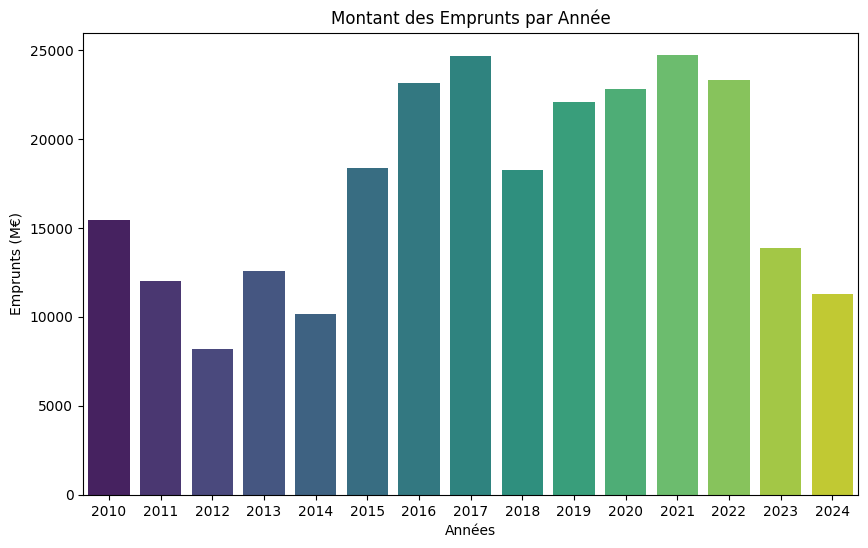

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df['date'] = pd.to_datetime(df['date'])
df['annee'] = df['date'].dt.year

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='annee', y='emprunts_M€', errorbar=None, palette='viridis')

plt.title("Montant des Emprunts par Année")
plt.xlabel("Années")
plt.ylabel("Emprunts (M€)")

plt.show()

In [ ]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

    df['annee'] = df['date'].dt.year
    df['mois'] = df['date'].dt.month
    df['jour'] = df['date'].dt.day

    if 'emprunts_M€' in df.columns:
        df = df.rename(columns={'emprunts_M€': 'emprunts'})
        
    df = df.drop(columns=['date'])
    print("Transformation réussie !")
else:
    print("La colonne 'date' n'existe pas ou a déjà été supprimée et séparée.")

print(df.head())

La colonne 'date' n'existe pas ou a déjà été supprimée et séparée.
   emprunts  annee  mois  jour
0     16442   2024     7     1
1     13017   2024     6     1
2     10709   2024     5     1
3     10817   2024     4     1
4      9751   2024     3     1


## ----------------------------------------------
## ---------------------------------------------
## ---------------------------------------------

##  2 foyers_ficaux 

In [74]:
dossier = Path("data/raw")


dossier = Path(r"C:\Users\DELL\Desktop\Masteroffic\Mastere Data engenner\M1\ETL\projet\projetetlimolocal\data\raw")

nom_fichier = "foyers_fiscaux.csv" 

df1 = pd.read_csv(dossier / nom_fichier)
print(df1.columns)
print(df1.isnull().sum())
df1 = df1.rename(columns={'date': 'annee'})
#colonnes_numeriques = df.select_dtypes(include=['number'])
#print((colonnes_numeriques < 0).sum())
print(df1.columns)

Index(['date', 'departement', 'id_ville', 'ville', 'n_foyers_fiscaux',
       'revenu_fiscal_moyen', 'montant_impot_moyen', 'n_foyers_0k_10k',
       'n_foyers_10k_12k', 'n_foyers_12k_15k', 'n_foyers_15k_20k',
       'n_foyers_20k_30k', 'n_foyers_30k_50k', 'n_foyers_50k_100k',
       'n_foyers_100k_plus'],
      dtype='object')
date                        0
departement                 0
id_ville                    0
ville                       0
n_foyers_fiscaux          484
revenu_fiscal_moyen       821
montant_impot_moyen       830
n_foyers_0k_10k        264376
n_foyers_10k_12k       266186
n_foyers_12k_15k       264378
n_foyers_15k_20k       264375
n_foyers_20k_30k       264375
n_foyers_30k_50k       264375
n_foyers_50k_100k      268520
n_foyers_100k_plus     270307
dtype: int64
Index(['annee', 'departement', 'id_ville', 'ville', 'n_foyers_fiscaux',
       'revenu_fiscal_moyen', 'montant_impot_moyen', 'n_foyers_0k_10k',
       'n_foyers_10k_12k', 'n_foyers_12k_15k', 'n_foyers_15k_20

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste de toutes tes colonnes à afficher
colonnes = [
    'annee', 'departement', 'id_ville', 'ville', 'n_foyers_fiscaux', 
    'revenu_fiscal_moyen', 'montant_impot_moyen', 'n_foyers_0k_10k', 
    'n_foyers_10k_12k', 'n_foyers_12k_15k', 'n_foyers_15k_20k', 
    'n_foyers_20k_30k', 'n_foyers_30k_50k', 'n_foyers_50k_100k', 
    'n_foyers_100k_plus'
]

for col in colonnes:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        
        if col in ['ville', 'departement'] and df[col].nunique() > 15:
            sns.countplot(data=df1, y=col, order=df[col].value_counts().index[:10], palette='viridis')
            plt.title(f"Top 10 des valeurs pour la colonne : {col}")
            
        else:
            sns.histplot(data=df1, x=col, kde=True, color='teal')
            plt.title(f"Distribution de la colonne : {col}")
            
        plt.xlabel(col)
        plt.ylabel("Nombre de lignes (Fréquence)")
        plt.tight_layout()
        plt.show()

## --------------------------------------------------
## --------------------------------------------------
## -------------------------------------------------

## 3 indice_reference_loyers

In [67]:
dossier = Path("data/raw")


dossier = Path(r"C:\Users\DELL\Desktop\Masteroffic\Mastere Data engenner\M1\ETL\projet\projetetlimolocal\data\raw")

nom_fichier = "indice_reference_loyers.csv" 

df2 = pd.read_csv(dossier / nom_fichier)
print(df2.head(3))
print(df2.isnull().sum())
#colonnes_numeriques = df.select_dtypes(include=['number'])
#print((colonnes_numeriques < 0).sum())
print(df2.info())


      quarter     IRL
0  2024-04-01  145.17
1  2024-01-01  143.46
2  2023-10-01  142.06
quarter    0
IRL        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   quarter  87 non-null     object 
 1   IRL      87 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.5+ KB
None


In [68]:
df2.columns = df2.columns.str.strip()

df2['quarter'] = pd.to_datetime(df2['quarter'])

df2['annee'] = df2['quarter'].dt.year
df2['mois'] = df2['quarter'].dt.month
df2['jour'] = df2['quarter'].dt.day

df2 = df2.drop(columns=['quarter'])

print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IRL     87 non-null     float64
 1   annee   87 non-null     int32  
 2   mois    87 non-null     int32  
 3   jour    87 non-null     int32  
dtypes: float64(1), int32(3)
memory usage: 1.8 KB
None


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(data=df2, x='annee', y='IRL', marker='o', color='b', linewidth=2.5)
plt.title("Évolution de l'IRL par Année", fontsize=14, fontweight='bold')
plt.xlabel("Années", fontsize=12)
plt.ylabel("Valeur de l'IRL", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=df2, x='mois', y='IRL', errorbar=None, palette='coolwarm')
plt.title("Valeur Moyenne de l'IRL par Mois", fontsize=14, fontweight='bold')
plt.xlabel("Mois", fontsize=12)
plt.ylabel("IRL Moyen", fontsize=12)
plt.show()

## -------------------------------------------
## -------------------------------------------
## -------------------------------------------

## 04 -Loyers

In [71]:
dossier = Path("data/raw")


dossier = Path(r"C:\Users\DELL\Desktop\Masteroffic\Mastere Data engenner\M1\ETL\projet\projetetlimolocal\data\raw")

nom_fichier = "loyers.csv" 

df3 = pd.read_csv(dossier / nom_fichier)
print(df3.columns)
print(df3.isnull().sum())
#colonnes_numeriques = df.select_dtypes(include=['number'])
#print((colonnes_numeriques < 0).sum())
print(df3.info())


Index(['departement', 'id_ville', 'ville', 'date', 'loyer_m2_appartement',
       'loyer_m2_maison'],
      dtype='object')
departement             0
id_ville                0
ville                   0
date                    0
loyer_m2_appartement    0
loyer_m2_maison         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105391 entries, 0 to 105390
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   departement           105391 non-null  object 
 1   id_ville              105391 non-null  int64  
 2   ville                 105391 non-null  object 
 3   date                  105391 non-null  int64  
 4   loyer_m2_appartement  105391 non-null  float64
 5   loyer_m2_maison       105391 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 4.8+ MB
None


In [72]:
colonnes_numeriques = df3.select_dtypes(include=['number'])

valeurs_negatives = (colonnes_numeriques < 0).sum()

print("--- Vérification des valeurs négatives ---")
print(valeurs_negatives[valeurs_negatives > 0])

if (valeurs_negatives == 0).all():
    print("Parfait ! Aucune valeur négative trouvée dans les colonnes numériques.")

--- Vérification des valeurs négatives ---
Series([], dtype: int64)
Parfait ! Aucune valeur négative trouvée dans les colonnes numériques.
